In [ ]:
import os
import json
import torch
import pandas as pd
from typing import Dict
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from datasets import Dataset
import transformers
from torch.utils.data import IterableDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForSeq2Seq, TrainingArguments, Trainer, GenerationConfig, EarlyStoppingCallback
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from accelerate import Accelerator

# 训练部分

## 数据加载

In [ ]:
# 读取joson，然后转化dataframe
def load_jsonl(path):
    with open(path, "r") as file:
        data = [json.loads(line) for line in file]
        return data

In [ ]:
def view_data_distribution(data_path, show_first=False):
    df = load_jsonl(data_path)
    print(f"total_count:{df.shape[0]}, true_count: {df['label'].sum()}, false_count: {(df['label']==False).sum()}")
    print(json.dumps(df.iloc[0].to_dict(), indent=4, ensure_ascii=False)) if show_first else None

## 数据预处理

In [ ]:
def preprocess(item, tokenizer, with_reason=False, max_length=2048, instruction=None):
    system_message = "You are a helpful assistant."
    instruction = item['instruction'] if not instruction else instruction
    user_message = instruction + '\n' + item['input']
    
    if with_reason: 
        output = {"is_fraud": item["label"], "fraud_speaker": item["fraud_speaker"], "reason": item["reason"]}
    else:
        output = {"is_fraud": item["label"]}
        
    # 把字段转化成了字符串
    assistant_message = json.dumps(output, ensure_ascii=False)
    
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message},
        {"role": "assistant", "content": assistant_message}
    ]
    
    full_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        max_length=max_length,
        truncation=True
    )
    
    # messages[:-1] 代表只要 system + user，不要最后的 assistant 
    prompt_ids = tokenizer.apply_chat_template(
        messages[:-1],
        tokenize=True,
        add_generation_prompt=True # 必须为 True，用来补全 assistant 的开头引导符
    )
    
    
    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    attention_mask = [1] * len(full_ids)
    return {
        "input_ids": full_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
class LazySupervisedDataset(Dataset):
    """Dataset for supervised fine-tuning."""
    
    def __init__(self, raw_data, tokenizer: transformers.PreTrainedTokenizer, with_reason=False, max_len: int = 1024, instruction=None):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.raw_data = raw_data
        self.with_reason = with_reason
        self.instruction=instruction
        self.cached_data_dict = {}
        
        
    def __len__(self):
        return len(self.raw_data)
    
    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        if isinstance(i, list):
            ret = [preprocess(self.raw_data[j], self.tokenizer, self.with_reason, self.max_len, self.instruction) for j in i]
        elif isinstance(i, int):
            ret = [preprocess(self.raw_data[i], self.tokenizer, self.with_reason, self.max_len, self.instruction)]
        else:  
            raise TypeError("Index must be an int or a list of ints")  
        
        # dataframe 这里把ret的序列进行合并，然后df["input_ids"]的多个序列进行合并 
        df = pd.DataFrame(ret)
        
        # 转化成字典发过去
        return dict(
            input_ids = df["input_ids"],
            labels = df["labels"],
            attention_mask = df["attention_mask"]
        )

In [ ]:
def load_one_dataset(data_path, tokenizer, with_reason:bool, lazy:bool, instruction=None):
    df = load_jsonl(data_path)
    ds = Dataset.from_pandas(df)
    if lazy:
        return LazySupervisedDataset(ds, tokenizer, with_reason)
    else:
        return ds.map(
            lambda x: preprocess(x, tokenizer, with_reason=with_reason, instruction=instruction),
            remove_columns=ds.column_names
        )

In [ ]:
def load_dataset(train_path, eval_path, tokenizer, with_reason=False, lazy=True, instruction=None):
    train_dataset = load_one_dataset(train_path, tokenizer, with_reason, lazy, instruction)
    eval_dataset = load_one_dataset(eval_path, tokenizer, with_reason, lazy, instruction)
    return train_dataset, eval_dataset

## 创建模型

In [ ]:
def load_model(model_path, device='cuda'):
    tokenizer = AutoTokenizer.from_pretrained(model_path, padding_side="left", use_fast=False, trust_remote_code=True)
    # torch_dtype控制参数加载的精度
    model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16)
    return model.to(device), tokenizer

In [ ]:
def build_loraconfig():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM, 
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        inference_mode=False, # 训练模式
        r=8, 
        lora_alpha=16,   
        lora_dropout=0.05
    )

## 准备训练

In [ ]:
def build_train_arguments(output_path):
    return TrainingArguments(
        output_dir=output_path,
        per_device_train_batch_size=16,  # 每个设备（如每个GPU）的训练批次大小
        gradient_accumulation_steps=1,  # 梯度累积的步骤数，相当于增大批次大小
        log_level="warning",
        log_level_replica="warning",
        logging_steps=10,  
        logging_first_step=True, # 是否在训练的第一步就记录日志
        logging_dir=os.path.join(output_path, "logs"),
        weight_decay=0.01,     # 引入权重衰减，它会迫使模型参数保持较小的值，从而避免模型过拟合
        warmup_ratio=0.05,     # 前5%的steps用于预热学习率
        num_train_epochs=3,    # 训练的总轮数
        per_device_eval_batch_size=8,  # 每个设备（如每个GPU）的预测批次大小
        eval_strategy="steps",  # 设置评估策略为steps
        eval_on_start=False,    # 在训练开始时就进行模型评估
        eval_steps=100,  # 设置评估的步数，与保存步数一致
        save_steps=100, # 为了快速演示，这里设置10，建议你设置成100
        learning_rate=1e-4,
        bf16=True,                   # 使用混合精度来进行矩阵计算，bf16范围大精度低，在数值稳定性上比fp16表现更好，
        lr_scheduler_type="cosine",  # 使用余弦退火调度器，在训练过程中逐渐减小学习率，有助于模型稳定收敛。
        save_on_each_node=True,
        load_best_model_at_end=True, # 在训练结束时加载最佳模型
        remove_unused_columns=False, # 
        dataloader_drop_last=True,   # 抛弃最后一批迭代数据（可能数量不满足一批）
        gradient_checkpointing=True  #  启用梯度检查点以节省内存
    )

In [ ]:
def build_trainer(model, tokenizer, train_args, lora_config, train_dataset, eval_dataset):
    peft_model = get_peft_model(model, lora_config)
    peft_model.print_trainable_parameters()
    # 开启梯度检查点时，要执行该方法
    if train_args.gradient_checkpointing:
        peft_model.enable_input_require_grads()
        
    return Trainer(
        model=peft_model,
        args=train_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],  # 这里是如果连续5次检查都没变小就停止
    )

# 测试部分


In [2]:
import os
import json
import re
import torch
from typing import List, Dict
from tqdm import *
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from peft import PeftModel
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

e:\anaconda3\envs\peft\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 读取joson，然后转化dataframe
def load_jsonl(path):
    with open(path, "r") as file:
        data = [json.loads(line) for line in file]
        return data

In [ ]:
def load_model(model_path, checkpoint_path='', device='cuda'):
    # tokenizer, padding left 是因为，在生成情况下一般使用的自回归模型，所以这里使用左侧填充
    tokenizer = AutoTokenizer.from_pretrained(model_path, padding_side="left", trust_remote_code=True)
    # 加载模型
    model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16, trust_remote_code=True).eval().to(device)
    # 加载lora权重
    if checkpoint_path: 
        model = PeftModel.from_pretrained(model, model_id=checkpoint_path).to(device)
    
    return model, tokenizer
    

In [ ]:
def safe_loads(text, default_value=None):
    json_string = re.sub(r'^```json\n(.*)\n```$', r'\1', text.strip(), flags=re.DOTALL)
    try:  
        return json.loads(json_string)  
    except json.JSONDecodeError as e:  
        print(f"invalid json: {json_string}")
        return default_value  

In [5]:
def build_prompt(content, instruction=None):
    if not instruction:
        instruction = "下面是一段对话文本, 请分析对话内容是否有诈骗风险，只以json格式输出你的判断结果(is_fraud: true/false)。"
    prompt = f"{instruction}\n{content}"
    return [{"role": "user", "content": prompt}]

In [1]:
# 添加特殊的token，
def predict(model, tokenizer, content, device='cuda'):
    inputs = tokenizer.apply_chat_template(build_prompt(content),
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_tensors="pt", # 这里 pt 可以吧数据给转化成batch形式，直接转化成[batch_size, sequence_length]
                                           return_dict=True).to(device)
    default_response = {'is_fraud':False}
    gen_kwargs = {"max_new_tokens": 2048, "do_sample": True, "top_k": 1} # 这里do smaple 他的功能是可以让模型不要总是永远选择概率最高的那个词
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)
        outputs = outputs[:, inputs["input_ids"].shape[1]:]
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        return safe_loads(response, default_response)

In [9]:
def run_test(model, tokenizer, test_data, device = "cuda"):
    real_labels = []
    pred_labels = []
    pbar = tqdm(total=len(test_data), desc=f"progress")
    
    for i, item in enumerate(test_data):
        dialog_input = item["input"]
        real_label = item["label"]
        
        prediction = predict(model, tokenizer, dialog_input, device)
        pred_label = prediction["is_fraud"]
        
        real_labels.append(real_label)
        pred_labels.append(pred_label)
        
        pbar.update(1)
        
    pbar.close()
    return real_labels, pred_labels

In [3]:
from typing import List

def predict_batch(model, tokenizer, contents: List[str], device='cuda', instruction=None):
    prompts = [build_prompt(content, instruction) for content in contents]
    inputs = tokenizer(
        tokenizer.apply_chat_template(prompts, add_generation_prompt = True, tokenize = False),
        padding = True,
        return_tensors = "pt"
    ).to(device)
    
    default_response = {'is_fraud': False}
    gen_kwargs = {"max_new_tokens": 2048, "do_sample": True, "top_k": 1}
    
    with torch.inference_mode():
        outputs = model.generate(**inputs, **gen_kwargs)
        new_tokens = outputs[:, inputs["input_ids"].shape[1]:]
        response_string = tokenizer.batch_decode(new_tokens, skip_special_tokens = True)
    
    responses  = [safe_loads(text, default_response) for text in response_string]
    
    return responses 

In [4]:
def run_test_batch(model, tokenizer, test_data: List[Dict], batch_size: int = 128, device='cuda'):
    real_labels = []
    pred_labels = []
    pbar = tqdm(total=len(test_data), desc=f'progress')
    
    for i in range(0, len(test_data), batch_size):
        batch_data = test_data[i:i + batch_size]
        dialog_inputs = [item['input'] for item in batch_data]
        real_batch_labels = [item['label'] for item in batch_data]
        
        predictions = predict_batch(model, tokenizer, dialog_inputs, device)
        pred_batch_labels = [prediction['is_fraud'] for prediction in predictions]
        
        real_labels.extend(real_batch_labels)
        pred_labels.extend(pred_batch_labels)
        
        pbar.update(len(batch_data))

    pbar.close()
    return real_labels, pred_labels

NameError: name 'Dict' is not defined

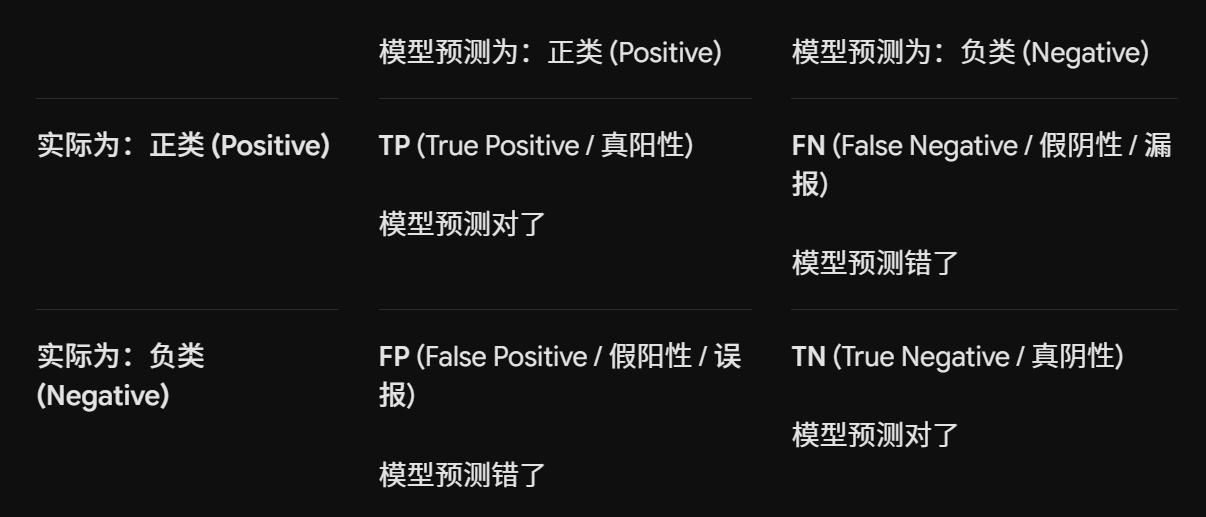


1. 精准度 (Precision)
   1. 原理： 在模型所有预测为“正类”的样本中，到底有多少是真正的“正类”？
   2. $Precision = \frac{TP}{TP + FP}$
2. 召回率 (Recall)
   1. 原理： 在所有实际为“正类”的样本中，模型成功找出来（召回）了多少？
   2. $Recall = \frac{TP}{TP + FN}$
3. 准确率
   1. 在所有的样本中，模型整体预测正确的比例是多少？
   2. $Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$

In [ ]:
def precision_recall(true_labels, pred_labels, labels=None, debug=False):
    cm = confusion_matrix(true_labels, pred_labels, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    print(f"tn：{tn}, fp:{fp}, fn:{fn}, tp:{tp}") if debug else None
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    accuracy = (tp + tn)/(tn + fn + tp + fp)
    return precision, recall, accuracy

In [ ]:


def evaluate_with_model(model, tokenizer, testdata_path, device='cuda', batch=True, debug=False):
    dataset = load_jsonl(testdata_path)
    run_test_func = run_test_batch if batch else run_test
    true_labels, pred_labels = run_test_func(model, tokenizer, dataset, device=device)
    precision, recall, accuracy = precision_recall(true_labels, pred_labels, debug=debug)
    print(f"precision: {precision}, recall: {recall}, accuracy: {accuracy}")

def evaluate(model_path, checkpoint_path, testdata_path, device='cuda', batch=True, debug=False):    
    model, tokenizer = load_model(model_path, checkpoint_path, device)
    evaluate_with_model(model, tokenizer, testdata_path, device, batch, debug)